<a href="https://colab.research.google.com/github/pahsooch/CBA01-Michaelis-Menten-Case/blob/main/CBA01_Michaelis_Menten.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# **Michaelis Menten Kinetics Full Defined**

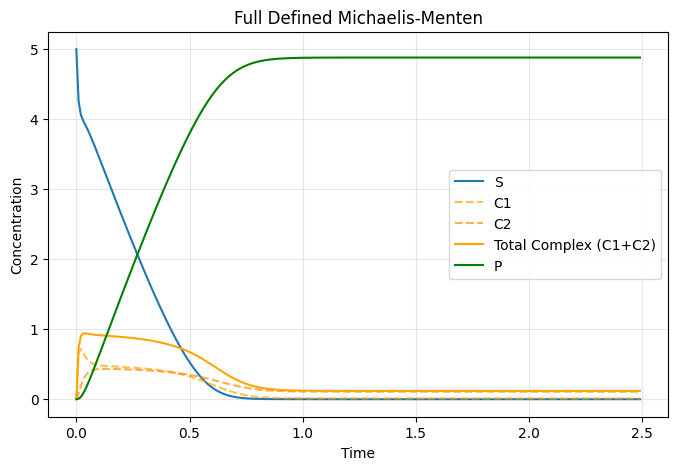

In [6]:
def full_network(y, t):
    # create container
    dydt = np.empty(4)

    # set parameters
    et = 1
    k1 = 30       # Laju maju S + E -> C1
    k_min1 = 1    # Laju mundur C1 -> S + E
    k2 = 20       # Laju transisi C1 -> C2
    k_min2 = 2    # Laju mundur transisi C2 -> C1
    k3 = 20       # Laju pelepasan produk C2 -> P + E
    k_min3 = 0.5  # Laju pengikatan kembali produk P + E -> C2

    # set dynamic variables
    s = y[0]
    c1 = y[1]
    c2 = y[2]
    p = y[3]

    # Substitusi enzim bebas (konservasi massa)
    e = et - c1 - c2

    # differential equations
    dydt[0] = -k1*s*e + k_min1*c1
    dydt[1] =  k1*s*e - k_min1*c1 - k2*c1 + k_min2*c2
    dydt[2] =  k2*c1 - k_min2*c2 - k3*c2 + k_min3*p*e
    dydt[3] =  k3*c2 - k_min3*p*e

    return dydt

# set initial condition [S, C1, C2, P]
init = [5, 0, 0, 0]

# set time points
t = np.arange(0, 2.5, 0.01)

# solve equations
y = odeint(full_network, init, t)

# extract variables for plotting
S = y[:, 0]
C1 = y[:, 1]
C2 = y[:, 2]
P = y[:, 3]
C_total = C1 + C2

# make figure
plt.figure(figsize=(8, 5))
plt.plot(t, S, label='S')
plt.plot(t, C1, label='C1', color='orange', linestyle='--', alpha=0.7)
plt.plot(t, C2, label='C2', color='darkorange', linestyle='--', alpha=0.7)
plt.plot(t, C_total, label='Total Complex (C1+C2)', color='orange')
plt.plot(t, P, label='P', color='green')

plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Full Defined Michaelis-Menten')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **Simplified Michaelis Menten**

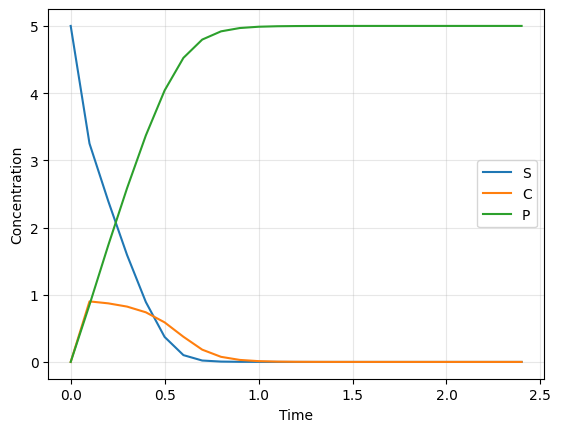

In [7]:

def network(y, t):
  #create container
  dydt = np.empty(3)

  #set parameters
  kf = 30
  kr = 1
  k2 = 10
  et = 1

  #set dynamic variables
  s = y[0]
  c = y[1]
  p = y[2]

  #differential equations
  dydt[0] = -kf*s*(et-c) + kr*c
  dydt[1] = -kr*c + kf*s*(et-c) - k2*c
  dydt[2] = k2*c
  return dydt

#set initial condition
init= [5, 0, 0]
#set time points
t= np.arange(0, 2.5, 0.1)
#solve equations
y = odeint(network, init, t)#solve ODE

#make figure
plt.figure()
plt.plot(t, y[:,0], label= 'S')
plt.plot(t, y[:,1], label= 'C')
plt.plot(t, y[:,2], label= 'P')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()